# Steam Review Sentiment Analysis

NLP mini-project: binary sentiment classification of Steam game reviews.

We collect balanced (positive / negative) review samples across **6 genres**, then build a baseline classifier (TF-IDF + Logistic Regression) and XLM-RoBERTa transformer and check how well sentiment patterns generalize across different game genres.

In [ ]:
pip install requests

## 1. Data Collection

We pull reviews directly from Steam's public API, collecting an equal number of positive and negative reviews for each game. This way the dataset is balanced from the start.

Each game belongs to one of 6 genres (shooter, roguelike, roleplay, strategy, simulation, survival), with 3 games per genre. Reviews are collected separately for English (main experiment) and Russian (cross-language test set).

In [ ]:
import os
import csv
import time
import requests

# -- Game config: {genre: {game_name: steam_app_id}} --
# The appid is the number in a game's store URL, e.g.
# https://store.steampowered.com/app/730/ -> appid = 730
GAMES = {
    "shooter": {
        "CS2":                   730,
        "Marathon":              3065800,
        "PAYDAY 3":              1272080,
    },
    "roguelike": {
        "The Binding of Isaac Rebirth": 250900,
        "Risk of Rain 2":               632360,
        "DRG Rogue Core":               2605790,
    },
    "roleplay": {
        "Baldurs Gate 3":          1086940,
        "Seven Deadly Sins Origin": 3679080,
        "Monster Hunter Wilds":     2246340,
    },
    "strategy": {
        "Dota 2":                            570,
        "Age of Empires II Definitive Edition": 813780,
        "Cities Skylines II":                949230,
    },
    "simulation": {
        "The Sims 4":      1222670,
        "EA SPORTS FC 26": 3405690,
        "Russian Fishing 4": 766570,
    },
    "survival": {
        "Rust":                 252490,
        "Escape the Backrooms": 1943950,
        "Necesse":              1169040,
    },
}

# How many reviews to collect per class (positive/negative) per language
LANG_TARGETS = {
    "english": 750,   # 750 pos + 750 neg = 1500 per game
    "russian": 500,   # 500 pos + 500 neg = 1000 per game
}

OUT_DIR = "steam_reviews"
SLEEP_BETWEEN_CALLS = 1.5    # rate-limiting
NUM_PER_PAGE = 100           # max Steam allows per request
REQUEST_TIMEOUT = 20
MAX_PAGES_PER_CLASS = 60     # safety cap so a sparse game can't loop forever

ENDPOINT = "https://store.steampowered.com/appreviews/{appid}"


def fetch_one_class(appid, language, review_type, target):
    """Paginate through reviews of ONE class (positive OR negative) until we hit `target`."""
    collected, seen, cursor, pages = [], set(), "*", 0
    while len(collected) < target and pages < MAX_PAGES_PER_CLASS:
        params = {
            "json": 1,
            "language": language,
            "review_type": review_type,
            "purchase_type": "all",
            "filter": "recent",
            "num_per_page": NUM_PER_PAGE,
            "cursor": cursor,
        }
        try:
            resp = requests.get(ENDPOINT.format(appid=appid),
                                params=params, timeout=REQUEST_TIMEOUT)
            data = resp.json()
        except Exception as e:
            print(f"      ! request error ({e}); stopping this class")
            break

        if data.get("success") != 1:
            break
        reviews = data.get("reviews", [])
        if not reviews:
            break

        added = 0
        for rev in reviews:
            rid = rev["recommendationid"]
            if rid in seen:
                continue
            seen.add(rid)
            author = rev.get("author", {}) or {}
            collected.append({
                "recommendationid": rid,
                "appid": appid,
                "language": language,
                "review": (rev.get("review") or "").replace("\n", " ").replace("\r", " ").strip(),
                "voted_up": rev.get("voted_up"), # sign of "Recommended" / "Not recommended"
                "votes_up": rev.get("votes_up", 0),
                "votes_funny": rev.get("votes_funny", 0),
                "weighted_vote_score": rev.get("weighted_vote_score", 0),
                "playtime_forever": author.get("playtime_forever", 0),
                "num_reviews": author.get("num_reviews", 0),
                "timestamp_created": rev.get("timestamp_created"),
            })
            added += 1
            if len(collected) >= target:
                break

        next_cursor = data.get("cursor")
        if not next_cursor or next_cursor == cursor or added == 0:
            break
        cursor = next_cursor
        pages += 1
        time.sleep(SLEEP_BETWEEN_CALLS)
    return collected


def safe_name(name):
    """Replace characters that are unsafe for filenames."""
    for ch in ' :/\\\'"':
        name = name.replace(ch, "_")
    return name


def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    summary = []
    for genre, games in GAMES.items():
        for name, appid in games.items():
            if appid is None:
                print(f"[SKIP] {genre}/{name}: appid not set")
                continue
            for lang, target in LANG_TARGETS.items():
                print(f"[{genre}] {name} | {lang} | appid={appid}")
                pos = fetch_one_class(appid, lang, "positive", target)
                print(f"      positive: {len(pos)}/{target}")
                neg = fetch_one_class(appid, lang, "negative", target)
                print(f"      negative: {len(neg)}/{target}")

                rows = pos + neg
                if not rows:
                    print("      (no reviews collected; skipping file)")
                    summary.append((genre, name, lang, 0, 0))
                    continue

                # one CSV per (genre, game, language)
                path = os.path.join(OUT_DIR, f"{genre}__{safe_name(name)}__{lang}.csv")
                with open(path, "w", newline="", encoding="utf-8") as f:
                    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
                    w.writeheader()
                    w.writerows(rows)

                if len(pos) < target or len(neg) < target:
                    print(f"      WARNING: under target -> imbalanced/short for {name} ({lang})")
                print(f"      saved {len(rows)} rows -> {path}")
                summary.append((genre, name, lang, len(pos), len(neg)))

    # final report — easy to see which games fell short
    print("\n==== COLLECTION SUMMARY ====")
    print(f"{'genre':12} {'game':36} {'lang':8} {'pos':>5} {'neg':>5}")
    for genre, name, lang, p, n in summary:
        flag = "  <-- short" if (p < LANG_TARGETS[lang] or n < LANG_TARGETS[lang]) else ""
        print(f"{genre:12} {name:36} {lang:8} {p:>5} {n:>5}{flag}")

main()

[shooter] CS2 | english | appid=730
      positive: 750/750
      negative: 750/750
      saved 1500 rows -> steam_reviews/shooter__CS2__english.csv
[shooter] CS2 | russian | appid=730
      positive: 500/500
      negative: 500/500
      saved 1000 rows -> steam_reviews/shooter__CS2__russian.csv
[shooter] Marathon | english | appid=3065800
      positive: 750/750
      negative: 750/750
      saved 1500 rows -> steam_reviews/shooter__Marathon__english.csv
[shooter] Marathon | russian | appid=3065800
      positive: 500/500
      negative: 500/500
      saved 1000 rows -> steam_reviews/shooter__Marathon__russian.csv
[shooter] PAYDAY 3 | english | appid=1272080
      positive: 750/750
      negative: 750/750
      saved 1500 rows -> steam_reviews/shooter__PAYDAY_3__english.csv
[shooter] PAYDAY 3 | russian | appid=1272080
      positive: 500/500
      negative: 500/500
      saved 1000 rows -> steam_reviews/shooter__PAYDAY_3__russian.csv
[roguelike] The Binding of Isaac Rebirth | english

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Baseline: TF-IDF + Logistic Regression

Our baseline approach:
1. **TF-IDF** vectorization — turns review text into numerical features based on how important each word is
2. **Logistic Regression** — a simple but strong linear classifier, good starting point for text

We evaluate the model in two ways:
- **In-genre**: train and test on reviews from the same genre (standard 80/20 split) — how well can it learn sentiment *within* a genre?
- **LOGO (Leave-One-Genre-Out)**: train on 5 genres, test on the held-out one — does the model learn *general* sentiment, or just genre-specific words?

The gap between in-genre and LOGO scores tells us how much the model relies on genre-specific vocabulary vs. truly understanding sentiment.

In [2]:
import os

DATA_DIR = "steam_reviews"
RESULTS_DIR = "baseline_results"

LANGUAGE = "english"
GENRES = ["roguelike", "roleplay", "shooter", "simulation", "strategy", "survival"]

TFIDF_PARAMS = {
    "max_features": 50_000,        # keep top 50k words/bigrams
    "ngram_range": (1, 2),         # unigrams + bigrams
    "min_df": 3,                   # ignore super rare words (appear in < 3 reviews)
    "max_df": 0.95,                # ignore words that appear in almost every review
    "sublinear_tf": True,          # use log(tf) so frequent words don't dominate
    "strip_accents": "unicode",
    "dtype": "float64",
}

# Logistic Regression
LR_PARAMS = {
    "C": 1.0,
    "class_weight": "balanced",    # handles class imbalance automatically
    "max_iter": 1000,
    "solver": "lbfgs",
    "random_state": 42,
}

MIN_REVIEW_LENGTH = 3   # drop reviews shorter than 3 chars (empty/useless)
TEST_SIZE = 0.2          # 80% train / 20% test
RANDOM_STATE = 42

### Text Preprocessing

Steam reviews are messy: BBCode tags, URLs, heart emoji spam, non-ASCII characters. We clean all of that out and lowercase everything before feeding text to the model.

In [3]:
import re


def clean_review(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'\[/?[a-z0-9]+(?:=[^\]]*?)?\]', ' ', text)  # Steam BBCode tags: [b], [url=...], etc.
    text = re.sub(r'https?://\S+', ' ', text)                   # URLs
    text = re.sub(r'[♥♡]+', ' ', text)                          # heart spam (very common in Steam reviews)
    text = re.sub(r'[^\x00-\x7f]', ' ', text)                   # non-ASCII chars (emoji, CJK, etc.)
    text = re.sub(r'\s+', ' ', text).strip()                     # collapse whitespace
    return text

### Loading & Splitting the Data

Load all English review CSVs into one DataFrame and set up two kinds of train/test splits:
- **In-genre**: standard 80/20 within each genre
- **LOGO**: train on all genres except one, test on the held-out genre (checks cross-genre generalization)

In [4]:
import glob
import pandas as pd
from sklearn.model_selection import train_test_split


def load_all_english_reviews() -> pd.DataFrame:
    """Load all English CSVs, clean text, combine into one DataFrame."""
    pattern = os.path.join(DATA_DIR, f"*__{LANGUAGE}.csv")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No CSV files found matching {pattern}")

    frames = []
    for path in files:
        # filename format: genre__game__language.csv
        basename = os.path.splitext(os.path.basename(path))[0]
        parts = basename.split("__")
        genre, game = parts[0], parts[1]

        df = pd.read_csv(path)
        df = df.rename(columns={"review": "text"})
        df["genre"] = genre
        df["game"] = game
        df["label"] = df["voted_up"].map({True: 1, False: 0, "True": 1, "False": 0})
        frames.append(df[["genre", "game", "text", "label", "votes_funny"]])

    combined = pd.concat(frames, ignore_index=True)
    combined["text"] = combined["text"].apply(clean_review)

    # drop garbage reviews (empty strings, single characters, etc.)
    before = len(combined)
    combined = combined[combined["text"].str.len() >= MIN_REVIEW_LENGTH].reset_index(drop=True)
    print(f"Dropped {before - len(combined)} reviews shorter than {MIN_REVIEW_LENGTH} chars")

    return combined


def _split_genre(df, genre):
    """80/20 stratified split for one genre."""
    genre_df = df[df["genre"] == genre]
    train_df, test_df = train_test_split(
        genre_df,
        test_size=TEST_SIZE,
        stratify=genre_df["label"],
        random_state=RANDOM_STATE,
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


def get_in_genre_splits(df: pd.DataFrame):
    """Train and test within the SAME genre — standard evaluation."""
    for genre in GENRES:
        train_df, test_df = _split_genre(df, genre)
        yield genre, train_df, test_df


def get_logo_splits(df: pd.DataFrame):
    """Leave-One-Genre-Out: train on OTHER genres, test on the held-out one.
    Shows whether sentiment patterns transfer across game types."""
    for genre in GENRES:
        _, test_df = _split_genre(df, genre)

        # grab equal-sized samples from each of the other 5 genres
        other = df[df["genre"] != genre]
        n_train = int(len(df[df["genre"] == genre]) * (1 - TEST_SIZE))
        per_genre = n_train // (len(GENRES) - 1)

        sampled_parts = []
        for g in GENRES:
            if g == genre:
                continue
            g_df = other[other["genre"] == g]
            n = min(per_genre, len(g_df))
            sampled_parts.append(
                g_df.sample(n=n, random_state=RANDOM_STATE, replace=False)
            )
        train_df = pd.concat(sampled_parts, ignore_index=True)

        yield genre, train_df, test_df

### Evaluation & Plotting

Compute metrics (macro F1, accuracy, confusion matrix), save confusion matrix plots, and draw the generalization gap bar chart.

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)


def compute_metrics(y_true, y_pred) -> dict:
    report = classification_report(
        y_true, y_pred,
        target_names=["negative", "positive"],
        output_dict=True,
    )
    return {
        "macro_f1": round(f1_score(y_true, y_pred, average="macro"), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "classification_report": report,
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


def save_confusion_matrix(y_true, y_pred, name: str):
    plots_dir = os.path.join(RESULTS_DIR, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Negative", "Positive"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(name.replace("_", " ").title())
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, f"cm_{name}.png"), dpi=150)
    plt.close(fig)


def save_generalization_gap_chart(in_genre_results: dict, logo_results: dict):
    """Side-by-side bar chart: in-genre F1 vs. LOGO F1 for each genre."""
    plots_dir = os.path.join(RESULTS_DIR, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    genres = sorted(set(in_genre_results.keys()) & set(logo_results.keys()))
    in_genre_f1 = [in_genre_results[g]["macro_f1"] for g in genres]
    logo_f1 = [logo_results[g]["macro_f1"] for g in genres]

    x = np.arange(len(genres))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width / 2, in_genre_f1, width, label="In-genre F1", color="#4C72B0")
    bars2 = ax.bar(x + width / 2, logo_f1, width, label="LOGO F1", color="#DD8452")

    ax.set_ylabel("Macro F1")
    ax.set_title("TF-IDF + LR: In-Genre vs. LOGO (Generalization Gap)")
    ax.set_xticks(x)
    ax.set_xticklabels(genres, rotation=25, ha="right")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.bar_label(bars1, fmt="%.2f", fontsize=8, padding=2)
    ax.bar_label(bars2, fmt="%.2f", fontsize=8, padding=2)
    fig.tight_layout()
    fig.savefig(os.path.join(plots_dir, "generalization_gap.png"), dpi=150)
    plt.close(fig)


def extract_top_features(pipeline, n=20) -> dict:
    """Pull out the words with the highest/lowest LR coefficients —
    these are the words the model relies on most for its predictions."""
    feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()
    coefs = pipeline.named_steps["clf"].coef_[0]
    top_pos_idx = coefs.argsort()[-n:][::-1]
    top_neg_idx = coefs.argsort()[:n]
    return {
        "top_positive": [(feature_names[i], round(float(coefs[i]), 4)) for i in top_pos_idx],
        "top_negative": [(feature_names[i], round(float(coefs[i]), 4)) for i in top_neg_idx],
    }


def save_results(results: dict, filename: str):
    os.makedirs(RESULTS_DIR, exist_ok=True)
    path = os.path.join(RESULTS_DIR, filename)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False, default=str)
    print(f"Saved: {path}")

### Run the Baseline

Build the TF-IDF + Logistic Regression pipeline, run both in-genre and LOGO evaluations, print the summary table, and save everything to `baseline_results/`.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


def build_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
        ("clf", LogisticRegression(**LR_PARAMS)),
    ])


def run_in_genre(df):
    """Train & test within each genre, then all genres pooled together."""
    print("\n" + "=" * 60)
    print("IN-GENRE EVALUATION")
    print("=" * 60)
    results = {}

    for genre, train_df, test_df in get_in_genre_splits(df):
        pipe = build_pipeline()
        pipe.fit(train_df["text"], train_df["label"])
        y_pred = pipe.predict(test_df["text"])
        metrics = compute_metrics(test_df["label"], y_pred)
        results[genre] = metrics
        save_confusion_matrix(test_df["label"], y_pred, f"in_genre_{genre}")
        print(f"  {genre:>12s}  macro-F1={metrics['macro_f1']:.4f}  acc={metrics['accuracy']:.4f}")

    # also try training on ALL genres mixed together
    train_df, test_df = train_test_split(
        df, test_size=TEST_SIZE, stratify=df["label"], random_state=RANDOM_STATE,
    )
    pipe = build_pipeline()
    pipe.fit(train_df["text"], train_df["label"])
    y_pred = pipe.predict(test_df["text"])
    metrics = compute_metrics(test_df["label"], y_pred)
    results["all_pooled"] = metrics
    save_confusion_matrix(test_df["label"], y_pred, "in_genre_all_pooled")
    print(f"  {'all_pooled':>12s}  macro-F1={metrics['macro_f1']:.4f}  acc={metrics['accuracy']:.4f}")

    # show which words the model relies on most
    top_feats = extract_top_features(pipe)
    save_results(top_feats, "top_features.json")
    print(f"\n  Top positive: {[w for w, _ in top_feats['top_positive'][:10]]}")
    print(f"  Top negative: {[w for w, _ in top_feats['top_negative'][:10]]}")

    return results


def run_logo(df):
    """Leave-One-Genre-Out: can the model handle genres it hasn't seen?"""
    print("\n" + "=" * 60)
    print("LEAVE-ONE-GENRE-OUT (LOGO) EVALUATION")
    print("=" * 60)
    results = {}

    for genre, train_df, test_df in get_logo_splits(df):
        pipe = build_pipeline()
        pipe.fit(train_df["text"], train_df["label"])
        y_pred = pipe.predict(test_df["text"])
        metrics = compute_metrics(test_df["label"], y_pred)
        results[genre] = metrics
        save_confusion_matrix(test_df["label"], y_pred, f"logo_{genre}")
        print(f"  held-out {genre:>12s}  macro-F1={metrics['macro_f1']:.4f}  acc={metrics['accuracy']:.4f}"
              f"  (train={len(train_df)}, test={len(test_df)})")

    return results


def print_summary(in_genre_results, logo_results):
    """Compare in-genre vs. LOGO F1 — the gap shows how much
    the model depends on genre-specific words."""
    print("\n" + "=" * 60)
    print("SUMMARY: GENERALIZATION GAP")
    print("=" * 60)
    print(f"  {'Genre':>12s}  {'In-genre F1':>12s}  {'LOGO F1':>10s}  {'Gap':>8s}")
    print(f"  {'-'*12}  {'-'*12}  {'-'*10}  {'-'*8}")
    for genre in sorted(set(in_genre_results) & set(logo_results)):
        ig = in_genre_results[genre]["macro_f1"]
        lg = logo_results[genre]["macro_f1"]
        gap = ig - lg
        print(f"  {genre:>12s}  {ig:>12.4f}  {lg:>10.4f}  {gap:>+8.4f}")


# --- Run everything ---
print("Loading data...")
df = load_all_english_reviews()
print(f"Loaded {len(df)} reviews across {df['genre'].nunique()} genres, {df['game'].nunique()} games")

in_genre_results = run_in_genre(df)
logo_results = run_logo(df)

print_summary(in_genre_results, logo_results)
save_generalization_gap_chart(in_genre_results, logo_results)

save_results(
    {"in_genre": in_genre_results, "logo": logo_results},
    "baseline_results.json",
)
print("\nDone.")

Loading data...
Dropped 1489 reviews shorter than 3 chars
Loaded 25511 reviews across 6 genres, 18 games

IN-GENRE EVALUATION


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


     roguelike  macro-F1=0.8285  acc=0.8286


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


      roleplay  macro-F1=0.8401  acc=0.8406


...

  held-out   simulation  macro-F1=0.8439  acc=0.8439  (train=3350, test=839)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


  held-out     strategy  macro-F1=0.8133  acc=0.8139  (train=3330, test=833)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


  held-out     survival  macro-F1=0.8125  acc=0.8126  (train=3475, test=870)

SUMMARY: GENERALIZATION GAP
         Genre   In-genre F1     LOGO F1       Gap
  ------------  ------------  ----------  --------
     roguelike        0.8285      0.7626   +0.0659
      roleplay        0.8401      0.7890   +0.0511
       shooter        0.8577      0.7207   +0.1370
    simulation        0.8484      0.8439   +0.0045
      strategy        0.8195      0.8133   +0.0062
      survival        0.8182      0.8125   +0.0057
Saved: baseline_results/baseline_results.json

Done.


Setup XLM Roberta


In [7]:
!pip install -U transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.2 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


In [8]:
# ===== XLM-RoBERTa — fine-tuning =====
# Run the baseline cells first (same kernel): provides GENRES, TEST_SIZE, RANDOM_STATE,
# DATA_DIR, LANGUAGE, MIN_REVIEW_LENGTH, clean_review, get_in_genre_splits, get_logo_splits, compute_metrics.
import gc, time
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, set_seed,
)
set_seed(RANDOM_STATE)

MODEL_NAME     = "xlm-roberta-base"
TF_RESULTS_DIR = "transformer_results"
MAX_LENGTH     = 256
NUM_EPOCHS     = 3
TRAIN_BATCH    = 16
EVAL_BATCH     = 128
LEARNING_RATE  = 2e-5
WEIGHT_DECAY   = 0.01
N_FREEZE       = 6                      # freeze bottom 6 of 12 layers

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: no GPU detected. Fine-tuning on CPU will be very slow.\n"
          "Colab: Runtime > Change runtime type > GPU, then rerun.")

_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_collator  = DataCollatorWithPadding(_tokenizer)


def clean_review_light(text):
    """Light cleaning for transformer: keep case, punctuation, unicode; strip only BBCode + URLs."""
    if not isinstance(text, str): return ""
    text = re.sub(r'\[/?[a-z0-9]+(?:=[^\]]*?)?\]', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def load_for_transformer():
    """Load reviews with light cleaning, but use the same row-filter as baseline for fair comparison."""
    files = sorted(glob.glob(os.path.join(DATA_DIR, f"*__{LANGUAGE}.csv")))
    if not files: raise FileNotFoundError("No CSV files found")
    frames = []
    for path in files:
        genre, game = os.path.splitext(os.path.basename(path))[0].split("__")[:2]
        d = pd.read_csv(path).rename(columns={"review": "text"})
        d["genre"], d["game"] = genre, game
        d["label"] = d["voted_up"].map({True:1, False:0, "True":1, "False":0})
        frames.append(d[["genre","game","text","label","votes_funny"]])
    df = pd.concat(frames, ignore_index=True)
    heavy = df["text"].apply(clean_review)
    df["text"] = df["text"].apply(clean_review_light)
    keep = heavy.str.len() >= MIN_REVIEW_LENGTH
    print(f"Dropped {(~keep).sum()}; kept {keep.sum()} (rows match baseline)")
    return df[keep].reset_index(drop=True)


class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, enc, labels):
        self.enc, self.labels = enc, labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: self.enc[k][i] for k in self.enc}
        item["labels"] = int(self.labels[i])
        return item


def _freeze(model, n):
    """Freeze embeddings + bottom n encoder layers for faster fine-tuning."""
    for p in model.roberta.embeddings.parameters(): p.requires_grad = False
    for layer in model.roberta.encoder.layer[:n]:
        for p in layer.parameters(): p.requires_grad = False
    return model


def fit_predict_transformer(train_texts, train_labels, test_texts):
    """Fine-tune XLM-RoBERTa on train set and return predictions on test set."""
    train_ds = ReviewDataset(_tokenizer(list(train_texts), truncation=True, max_length=MAX_LENGTH),
                             list(train_labels))
    test_ds  = ReviewDataset(_tokenizer(list(test_texts),  truncation=True, max_length=MAX_LENGTH),
                             [0]*len(test_texts))
    model = _freeze(AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2), N_FREEZE)
    args = TrainingArguments(
        output_dir="tmp_trainer",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=0.1,
        save_strategy="no",
        eval_strategy="no",
        logging_strategy="no",
        report_to="none",
        fp16=(DEVICE == "cuda"),
        seed=RANDOM_STATE,
    )
    trainer = Trainer(model=model, args=args, train_dataset=train_ds, data_collator=_collator)
    trainer.train()
    preds = np.argmax(trainer.predict(test_ds).predictions, axis=-1)
    del trainer, model; gc.collect()
    if DEVICE == "cuda": torch.cuda.empty_cache()
    return preds


def _save_cm(y, p, name):
    d = os.path.join(TF_RESULTS_DIR, "plots"); os.makedirs(d, exist_ok=True)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y, p, display_labels=["Negative","Positive"], cmap="Oranges", ax=ax)
    ax.set_title(name.replace("_"," ").title()); fig.tight_layout()
    fig.savefig(os.path.join(d, f"cm_{name}.png"), dpi=150); plt.close(fig)


def _save_json(obj, fn):
    os.makedirs(TF_RESULTS_DIR, exist_ok=True)
    p = os.path.join(TF_RESULTS_DIR, fn)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)
    print("Saved:", p)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [9]:
# ===== Run: in-genre + LOGO (all_pooled dropped — it was the single most expensive run) =====
def run_in_genre_transformer(df):
    print("\nIN-GENRE — XLM-RoBERTa")
    res = {}
    for genre, tr, te in get_in_genre_splits(df):
        p = fit_predict_transformer(tr["text"], tr["label"], te["text"])
        res[genre] = compute_metrics(te["label"], p)
        _save_cm(te["label"], p, f"in_genre_{genre}")
        print(f"  {genre:>12s}  macro-F1={res[genre]['macro_f1']:.4f}")
    return res

def run_logo_transformer(df):
    print("\nLOGO — XLM-RoBERTa")
    res = {}
    for genre, tr, te in get_logo_splits(df):
        p = fit_predict_transformer(tr["text"], tr["label"], te["text"])
        res[genre] = compute_metrics(te["label"], p)
        _save_cm(te["label"], p, f"logo_{genre}")
        print(f"  held-out {genre:>12s}  macro-F1={res[genre]['macro_f1']:.4f}")
    return res

t0 = time.time()
df_tf = load_for_transformer()
print(f"{len(df_tf)} reviews | {df_tf['genre'].nunique()} genres | {df_tf['game'].nunique()} games")

tf_in_genre = run_in_genre_transformer(df_tf)
tf_logo     = run_logo_transformer(df_tf)

print("\nGENERALIZATION GAP — XLM-RoBERTa")
print(f"  {'Genre':>12s}  {'In-genre':>9s}  {'LOGO':>7s}  {'Gap':>7s}")
for g in sorted(set(tf_in_genre) & set(tf_logo)):
    ig, lg = tf_in_genre[g]["macro_f1"], tf_logo[g]["macro_f1"]
    print(f"  {g:>12s}  {ig:>9.4f}  {lg:>7.4f}  {ig-lg:>+7.4f}")

_save_json({"in_genre": tf_in_genre, "logo": tf_logo}, "transformer_results.json")
print(f"\nTotal: {(time.time()-t0)/60:.1f} min")

Dropped 1489; kept 25511 (rows match baseline)
25511 reviews | 6 genres | 18 games

IN-GENRE — XLM-RoBERTa


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


...

  held-out     strategy  macro-F1=0.8523


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


  held-out     survival  macro-F1=0.8437

GENERALIZATION GAP — XLM-RoBERTa
         Genre   In-genre     LOGO      Gap
     roguelike     0.8456   0.8262  +0.0194
      roleplay     0.8853   0.8738  +0.0115
       shooter     0.8829   0.7961  +0.0868
    simulation     0.8808   0.8641  +0.0167
      strategy     0.8631   0.8523  +0.0108
      survival     0.8413   0.8437  -0.0024
Saved: transformer_results/transformer_results.json

Total: 15.3 min


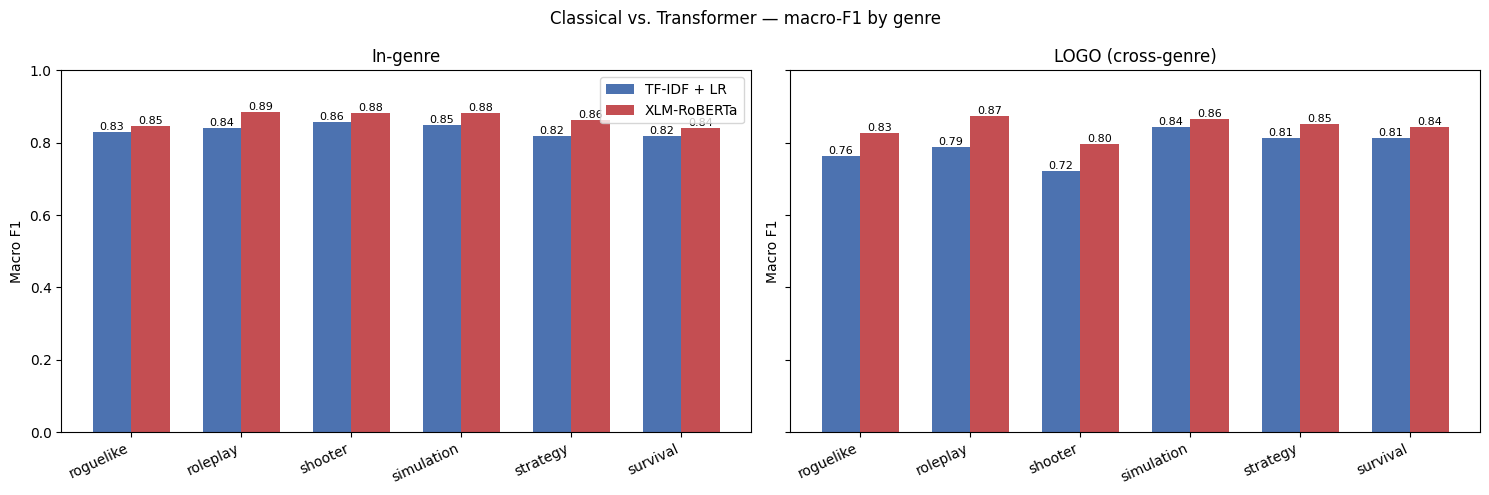

Saved: transformer_results/plots/classical_vs_transformer.png


In [10]:
with open(os.path.join("baseline_results", "baseline_results.json")) as f: base = json.load(f)
with open(os.path.join(TF_RESULTS_DIR,   "transformer_results.json")) as f: tf   = json.load(f)

genres = sorted(set(base["logo"]) & set(tf["logo"]))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, mode, title in [(axes[0], "in_genre", "In-genre"), (axes[1], "logo", "LOGO (cross-genre)")]:
    bf1 = [base[mode][g]["macro_f1"] for g in genres]
    tf1 = [tf[mode][g]["macro_f1"]   for g in genres]
    x, w = np.arange(len(genres)), 0.35
    b1 = ax.bar(x - w/2, bf1, w, label="TF-IDF + LR", color="#4C72B0")
    b2 = ax.bar(x + w/2, tf1, w, label="XLM-RoBERTa", color="#C44E52")
    ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(genres, rotation=25, ha="right")
    ax.set_ylim(0, 1); ax.set_ylabel("Macro F1")
    ax.bar_label(b1, fmt="%.2f", fontsize=8); ax.bar_label(b2, fmt="%.2f", fontsize=8)
axes[0].legend()
fig.suptitle("Classical vs. Transformer — macro-F1 by genre"); fig.tight_layout()
out = os.path.join(TF_RESULTS_DIR, "plots", "classical_vs_transformer.png")
os.makedirs(os.path.dirname(out), exist_ok=True); fig.savefig(out, dpi=150); plt.show()
print("Saved:", out)

# **Cross-Lingual Transfer**

Load Reviews


In [11]:
import os, glob, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

def load_reviews(language):
    files = sorted(glob.glob(os.path.join(DATA_DIR, f"*__{language}.csv")))
    if not files:
        raise FileNotFoundError(f"No CSVs for language='{language}' in {DATA_DIR}")
    frames = []
    for path in files:
        genre, game = os.path.splitext(os.path.basename(path))[0].split("__")[:2]
        d = pd.read_csv(path).rename(columns={"review": "text"})
        d["genre"], d["game"] = genre, game
        d["label"] = d["voted_up"].map({True:1, False:0, "True":1, "False":0})
        frames.append(d[["genre","game","text","label","votes_funny"]])
    df = pd.concat(frames, ignore_index=True)
    df["text"] = df["text"].apply(clean_review_light)   # NEVER clean_review() — it deletes Cyrillic
    df = df[df["text"].str.len() >= MIN_REVIEW_LENGTH].reset_index(drop=True)
    print(f"[{language}] {len(df)} reviews | overall pos={df['label'].mean():.1%}")
    print(df.groupby('genre')['label'].agg(n='size', pos_rate='mean').to_string())
    return df

df_en = load_reviews("english")
df_ru = load_reviews("russian")

[english] 26273 reviews | overall pos=49.7%
               n  pos_rate
genre                     
roguelike   4424  0.501130
roleplay    4387  0.495099
shooter     4429  0.502597
simulation  4306  0.491640
strategy    4337  0.493198
survival    4390  0.495444
[russian] 16619 reviews | overall pos=50.6%
               n  pos_rate
genre                     
roguelike   2908  0.496217
roleplay    2899  0.489479
shooter     2852  0.487728
simulation  2808  0.483262
strategy    2554  0.546594
survival    2598  0.537721


Evaluation Function + helpers

In [12]:
CL_DIR = "crosslingual_results"

def _cm(y, p, name, outdir, cmap="Greens"):
    d = os.path.join(outdir, "plots"); os.makedirs(d, exist_ok=True)
    fig, ax = plt.subplots(figsize=(5,4))
    ConfusionMatrixDisplay.from_predictions(y, p, display_labels=["Negative","Positive"], cmap=cmap, ax=ax)
    ax.set_title(name.replace("_"," ").title()); fig.tight_layout()
    fig.savefig(os.path.join(d, f"cm_{name}.png"), dpi=150); plt.close(fig)

def _json(obj, fn, outdir):
    os.makedirs(outdir, exist_ok=True)
    p = os.path.join(outdir, fn)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)
    print("Saved:", p)

def run_crosslingual_transformer(train_df, test_df, name):
    preds = fit_predict_transformer(train_df["text"], train_df["label"], test_df["text"])
    m = compute_metrics(test_df["label"], preds)
    _cm(test_df["label"], preds, name, CL_DIR)
    return m

Pooled

In [13]:
print("POOLED CROSS-LINGUAL TRANSFER")
pooled = {}
pooled["en_to_ru"] = run_crosslingual_transformer(df_en, df_ru, "pooled_en_to_ru")
pooled["ru_to_en"] = run_crosslingual_transformer(df_ru, df_en, "pooled_ru_to_en")
for k, m in pooled.items():
    print(f"  {k:10s}  macro-F1={m['macro_f1']:.4f}  acc={m['accuracy']:.4f}")

POOLED CROSS-LINGUAL TRANSFER


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


  en_to_ru    macro-F1=0.7725  acc=0.7742
  ru_to_en    macro-F1=0.8387  acc=0.8390



per-genre

In [14]:
print("PER-GENRE CROSS-LINGUAL TRANSFER")
per_genre = {}
for genre in GENRES:
    en_g, ru_g = df_en[df_en["genre"] == genre], df_ru[df_ru["genre"] == genre]
    if len(en_g) < 20 or len(ru_g) < 20:
        print(f"  {genre:>12s}  SKIPPED (en={len(en_g)}, ru={len(ru_g)})"); continue
    e2r = run_crosslingual_transformer(en_g, ru_g, f"{genre}_en_to_ru")
    r2e = run_crosslingual_transformer(ru_g, en_g, f"{genre}_ru_to_en")
    per_genre[genre] = {"en_to_ru": e2r, "ru_to_en": r2e}
    print(f"  {genre:>12s}  EN->RU F1={e2r['macro_f1']:.4f}   RU->EN F1={r2e['macro_f1']:.4f}")

PER-GENRE CROSS-LINGUAL TRANSFER


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Step,Training Loss


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


      survival  EN->RU F1=0.7554   RU->EN F1=0.8032



 chart

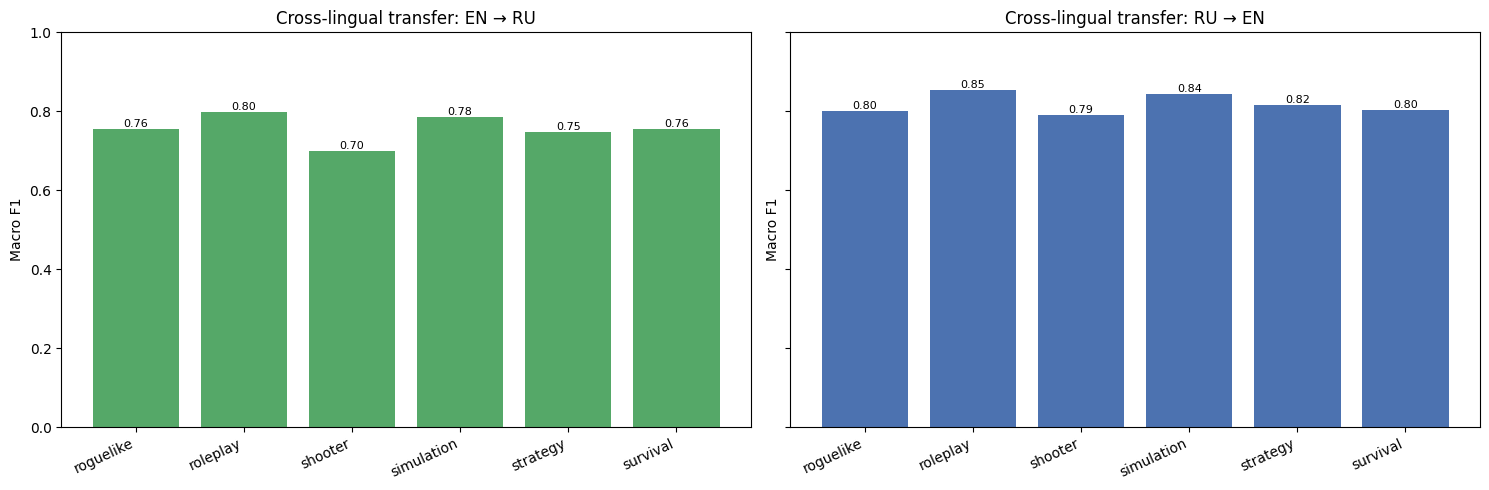

Saved: crosslingual_results/plots/crosslingual_transfer.png


In [15]:
genres = [g for g in GENRES if g in per_genre]
e2r = [per_genre[g]["en_to_ru"]["macro_f1"] for g in genres]
r2e = [per_genre[g]["ru_to_en"]["macro_f1"] for g in genres]
x = np.arange(len(genres))
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
for ax, vals, title, color in [(axes[0], e2r, "EN → RU", "#55A868"), (axes[1], r2e, "RU → EN", "#4C72B0")]:
    b = ax.bar(x, vals, color=color)
    ax.set_title(f"Cross-lingual transfer: {title}"); ax.set_ylim(0,1); ax.set_ylabel("Macro F1")
    ax.set_xticks(x); ax.set_xticklabels(genres, rotation=25, ha="right"); ax.bar_label(b, fmt="%.2f", fontsize=8)
fig.tight_layout()
out = os.path.join(CL_DIR, "plots", "crosslingual_transfer.png"); os.makedirs(os.path.dirname(out), exist_ok=True)
fig.savefig(out, dpi=150); plt.show(); print("Saved:", out)



 Save


In [16]:
_json({"pooled": pooled, "per_genre": per_genre}, "crosslingual_results.json", CL_DIR)

Saved: crosslingual_results/crosslingual_results.json


# **Sarcasm Failure Analysis**

combined frame, one split, train each model once

In [17]:
SARC_DIR = "sarcasm_results"
FUNNY_THRESHOLD = 2

def load_english_both_cleanings():
    files = sorted(glob.glob(os.path.join(DATA_DIR, "*__english.csv")))
    frames = []
    for path in files:
        genre, game = os.path.splitext(os.path.basename(path))[0].split("__")[:2]
        d = pd.read_csv(path).rename(columns={"review": "raw"})
        d["genre"], d["game"] = genre, game
        d["label"] = d["voted_up"].map({True:1, False:0, "True":1, "False":0})
        frames.append(d[["genre","game","raw","label","votes_funny"]])
    df = pd.concat(frames, ignore_index=True)
    df["text_heavy"] = df["raw"].apply(clean_review)        # TF-IDF (matches baseline)
    df["text_light"] = df["raw"].apply(clean_review_light)  # transformer + display
    return df[df["text_heavy"].str.len() >= MIN_REVIEW_LENGTH].reset_index(drop=True)  # baseline keep-rule

edf = load_english_both_cleanings()
tr, te = train_test_split(edf, test_size=TEST_SIZE, stratify=edf["label"], random_state=RANDOM_STATE)
te = te.reset_index(drop=True)

print("votes_funny percentiles:", {q: int(edf["votes_funny"].quantile(q)) for q in (0.5, 0.9, 0.95, 0.99)})
sarc_mask     = te["votes_funny"] >= FUNNY_THRESHOLD
straight_mask = te["votes_funny"] == 0
print(f"test={len(te)} | sarcastic(>={FUNNY_THRESHOLD})={sarc_mask.sum()} | straight(==0)={straight_mask.sum()}")
print(f"sarcastic pos-rate={te.loc[sarc_mask,'label'].mean():.1%} | "
      f"straight pos-rate={te.loc[straight_mask,'label'].mean():.1%}")

# train each model ONCE, predict full test, slice with masks
lr = build_pipeline(); lr.fit(tr["text_heavy"], tr["label"])
te["pred_lr"] = lr.predict(te["text_heavy"])
te["pred_tf"] = fit_predict_transformer(tr["text_light"], tr["label"], te["text_light"])

votes_funny percentiles: {0.5: 0, 0.9: 1, 0.95: 2, 0.99: 5}
test=5103 | sarcastic(>=2)=284 | straight(==0)=4253
sarcastic pos-rate=13.4% | straight pos-rate=54.6%


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:2043: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float64 'dtype' will be converted to np.float64.
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` inst

Step,Training Loss


summary

In [18]:
full_mask = pd.Series(True, index=te.index)
rows = [("all","All test", full_mask), ("sarcastic","Sarcastic", sarc_mask), ("straight","Straight", straight_mask)]
results = {"tfidf": {}, "transformer": {}}
print(f"{'Subset':12s} {'TF-IDF F1':>10s} {'Transf F1':>10s} {'N':>6s}")
for key, label, mask in rows:
    results["tfidf"][key]       = compute_metrics(te.loc[mask,"label"], te.loc[mask,"pred_lr"])
    results["transformer"][key] = compute_metrics(te.loc[mask,"label"], te.loc[mask,"pred_tf"])
    n = int(mask.sum()); warn = "  <-- small N!" if n < 20 else ""
    print(f"{label:12s} {results['tfidf'][key]['macro_f1']:>10.4f} "
          f"{results['transformer'][key]['macro_f1']:>10.4f} {n:>6d}{warn}")

gap_lr = results["tfidf"]["straight"]["macro_f1"]       - results["tfidf"]["sarcastic"]["macro_f1"]
gap_tf = results["transformer"]["straight"]["macro_f1"] - results["transformer"]["sarcastic"]["macro_f1"]
print(f"\nSarcasm gap (straight − sarcastic):  TF-IDF +{gap_lr:.4f}   Transformer +{gap_tf:.4f}")

Subset        TF-IDF F1  Transf F1      N
All test         0.8434     0.8734   5103
Sarcastic        0.7317     0.7841    284
Straight         0.8427     0.8742   4253

Sarcasm gap (straight − sarcastic):  TF-IDF +0.1110   Transformer +0.0901


chart

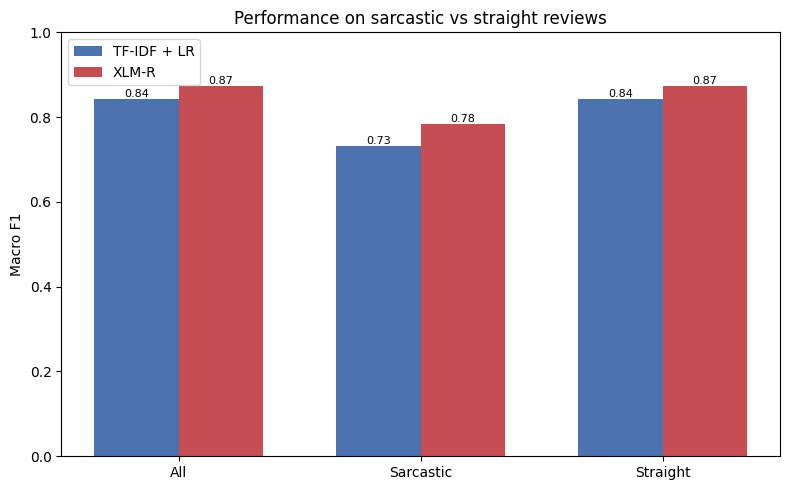

Saved: sarcasm_results/plots/sarcasm_vs_straight.png


In [19]:
groups = ["All", "Sarcastic", "Straight"]; keys = ["all","sarcastic","straight"]
lr_f1 = [results["tfidf"][k]["macro_f1"] for k in keys]
tf_f1 = [results["transformer"][k]["macro_f1"] for k in keys]
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x-w/2, lr_f1, w, label="TF-IDF + LR", color="#4C72B0")
b2 = ax.bar(x+w/2, tf_f1, w, label="XLM-R", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(groups); ax.set_ylim(0,1); ax.set_ylabel("Macro F1")
ax.set_title("Performance on sarcastic vs straight reviews"); ax.legend()
ax.bar_label(b1, fmt="%.2f", fontsize=8); ax.bar_label(b2, fmt="%.2f", fontsize=8)
fig.tight_layout()
out = os.path.join(SARC_DIR, "plots", "sarcasm_vs_straight.png"); os.makedirs(os.path.dirname(out), exist_ok=True)
fig.savefig(out, dpi=150); plt.show(); print("Saved:", out)

surface misclassified sarcastic reviews

In [20]:
def show_misclassified(col, model_name, k=12):
    miss = te[sarc_mask & (te[col] != te["label"])].sort_values("votes_funny", ascending=False)
    print(f"\n=== {model_name}: misclassified sarcastic reviews (top {k} by funny votes) ===")
    out = []
    for _, r in miss.head(k).iterrows():
        truth = "Recommended" if r["label"] else "Not Recommended"
        pred  = "Recommended" if r[col] else "Not Recommended"
        print(f"\n[funny={r['votes_funny']} | {r['genre']} | true={truth} | pred={pred}]\n{r['text_light'][:300]}")
        out.append({"votes_funny": int(r["votes_funny"]), "genre": r["genre"],
                    "true": int(r["label"]), "pred": int(r[col]), "text": r["text_light"][:500]})
    return out

mis_lr = show_misclassified("pred_lr", "TF-IDF + LR")
mis_tf = show_misclassified("pred_tf", "XLM-R")



=== TF-IDF + LR: misclassified sarcastic reviews (top 12 by funny votes) ===

[funny=166 | roleplay | true=Not Recommended | pred=Recommended]
Nobody will read my review so I Will Eat 1 Tablespoon of ketchup For Every Like this gets REDEEM CODE WELCOMEORIGIN ORIGINSTEAM ORIGINDISCORD ORIGINX [Ctrl+C,Ctrl+V] This game only has 2 things going for it. 1) The 7 Deadly Sins IP 2) It's a fresh Gacha so it has the new game appeal. lastly i really

[funny=47 | shooter | true=Recommended | pred=Not Recommended]
Stop looking at the launch reviews, it’s actually good now I get it. I was annoyed at launch too. The servers were busted, the progression system felt like a total grind, and it honestly felt like a unfinished mess. I uninstalled it and almost never looked back. But I jumped back in a few weeks ago 

[funny=12 | strategy | true=Recommended | pred=Not Recommended]
complacency, lazyness and undiscipline nearly killed this game and franchise, but now with a new dev studio that also contain

save


In [21]:
results["threshold"] = FUNNY_THRESHOLD
results["counts"] = {"total_test": int(len(te)),
                     "sarcastic_test": int(sarc_mask.sum()),
                     "straight_test": int(straight_mask.sum())}
results["misclassified_examples"] = {"tfidf": mis_lr, "transformer": mis_tf}
_json(results, "sarcasm_results.json", SARC_DIR)   # _json defined in Cell 4.2

Saved: sarcasm_results/sarcasm_results.json
